In [2]:
#Import necessary libraries
from scipy.stats import qmc
import numpy as np
import pandas as pd

from scipy.stats import norm
from scipy.optimize import minimize
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern

In [3]:
#Function 7
#Extracting updated data and turning it into a pandas dataframe
data = pd.read_csv('Data/Week 6 - Function 7.csv') 
columns = ['Input 1', 'Input 2','Input 3', 'Input 4', 'Input 5',
           'Input 6','Outputs']
#Remove columns with NaN values
data = data.dropna(axis = 1)
data.columns = columns
data

,Input 1,Input 2,Input 3,Input 4,Input 5,Input 6,Outputs
0,0.272624,0.324495,0.897109,0.832951,0.154063,0.795864,0.604433
1,0.543003,0.924694,0.341567,0.646486,0.718440,0.343133,0.562753
2,0.090832,0.661529,0.065931,0.258577,0.963453,0.640265,0.007503
3,0.118867,0.615055,0.905816,0.855300,0.413631,0.585236,0.061424
4,0.630218,0.838097,0.680013,0.731895,0.526737,0.348429,0.273047
5,0.764919,0.255883,0.609084,0.218079,0.322943,0.095794,0.083747
6,0.057896,0.491672,0.247422,0.218118,0.420428,0.730970,1.364968
7,0.195252,0.079227,0.554580,0.170567,0.014944,0.107032,0.092645
8,0.642303,0.836875,0.021793,0.101488,0.683071,0.692416,0.017870
9,0.789943,0.195545,0.575623,0.073659,0.259049,0.051100,0.033565


In [4]:
#Extract the Data Into Numpy Arrays
X = np.array(data[['Input 1', 'Input 2', 'Input 3', 'Input 4', 'Input 5'
                  ,'Input 6']])
Y = np.array(data[['Outputs']])


In [5]:
# Find the pearson correlations matrix
data.corr(method = 'pearson')

,Input 1,Input 2,Input 3,Input 4,Input 5,Input 6,Outputs
Input 1,1.000000,-0.115714,-0.112362,0.088539,0.038830,-0.560124,-0.517834
Input 2,-0.115714,1.000000,-0.044620,0.090419,0.304352,0.191700,0.042487
Input 3,-0.112362,-0.044620,1.000000,0.252070,-0.264841,0.020158,0.006030
Input 4,0.088539,0.090419,0.252070,1.000000,0.116760,-0.132378,-0.302433
Input 5,0.038830,0.304352,-0.264841,0.116760,1.000000,0.026116,-0.327917
Input 6,-0.560124,0.191700,0.020158,-0.132378,0.026116,1.000000,0.454052
Outputs,-0.517834,0.042487,0.006030,-0.302433,-0.327917,0.454052,1.000000


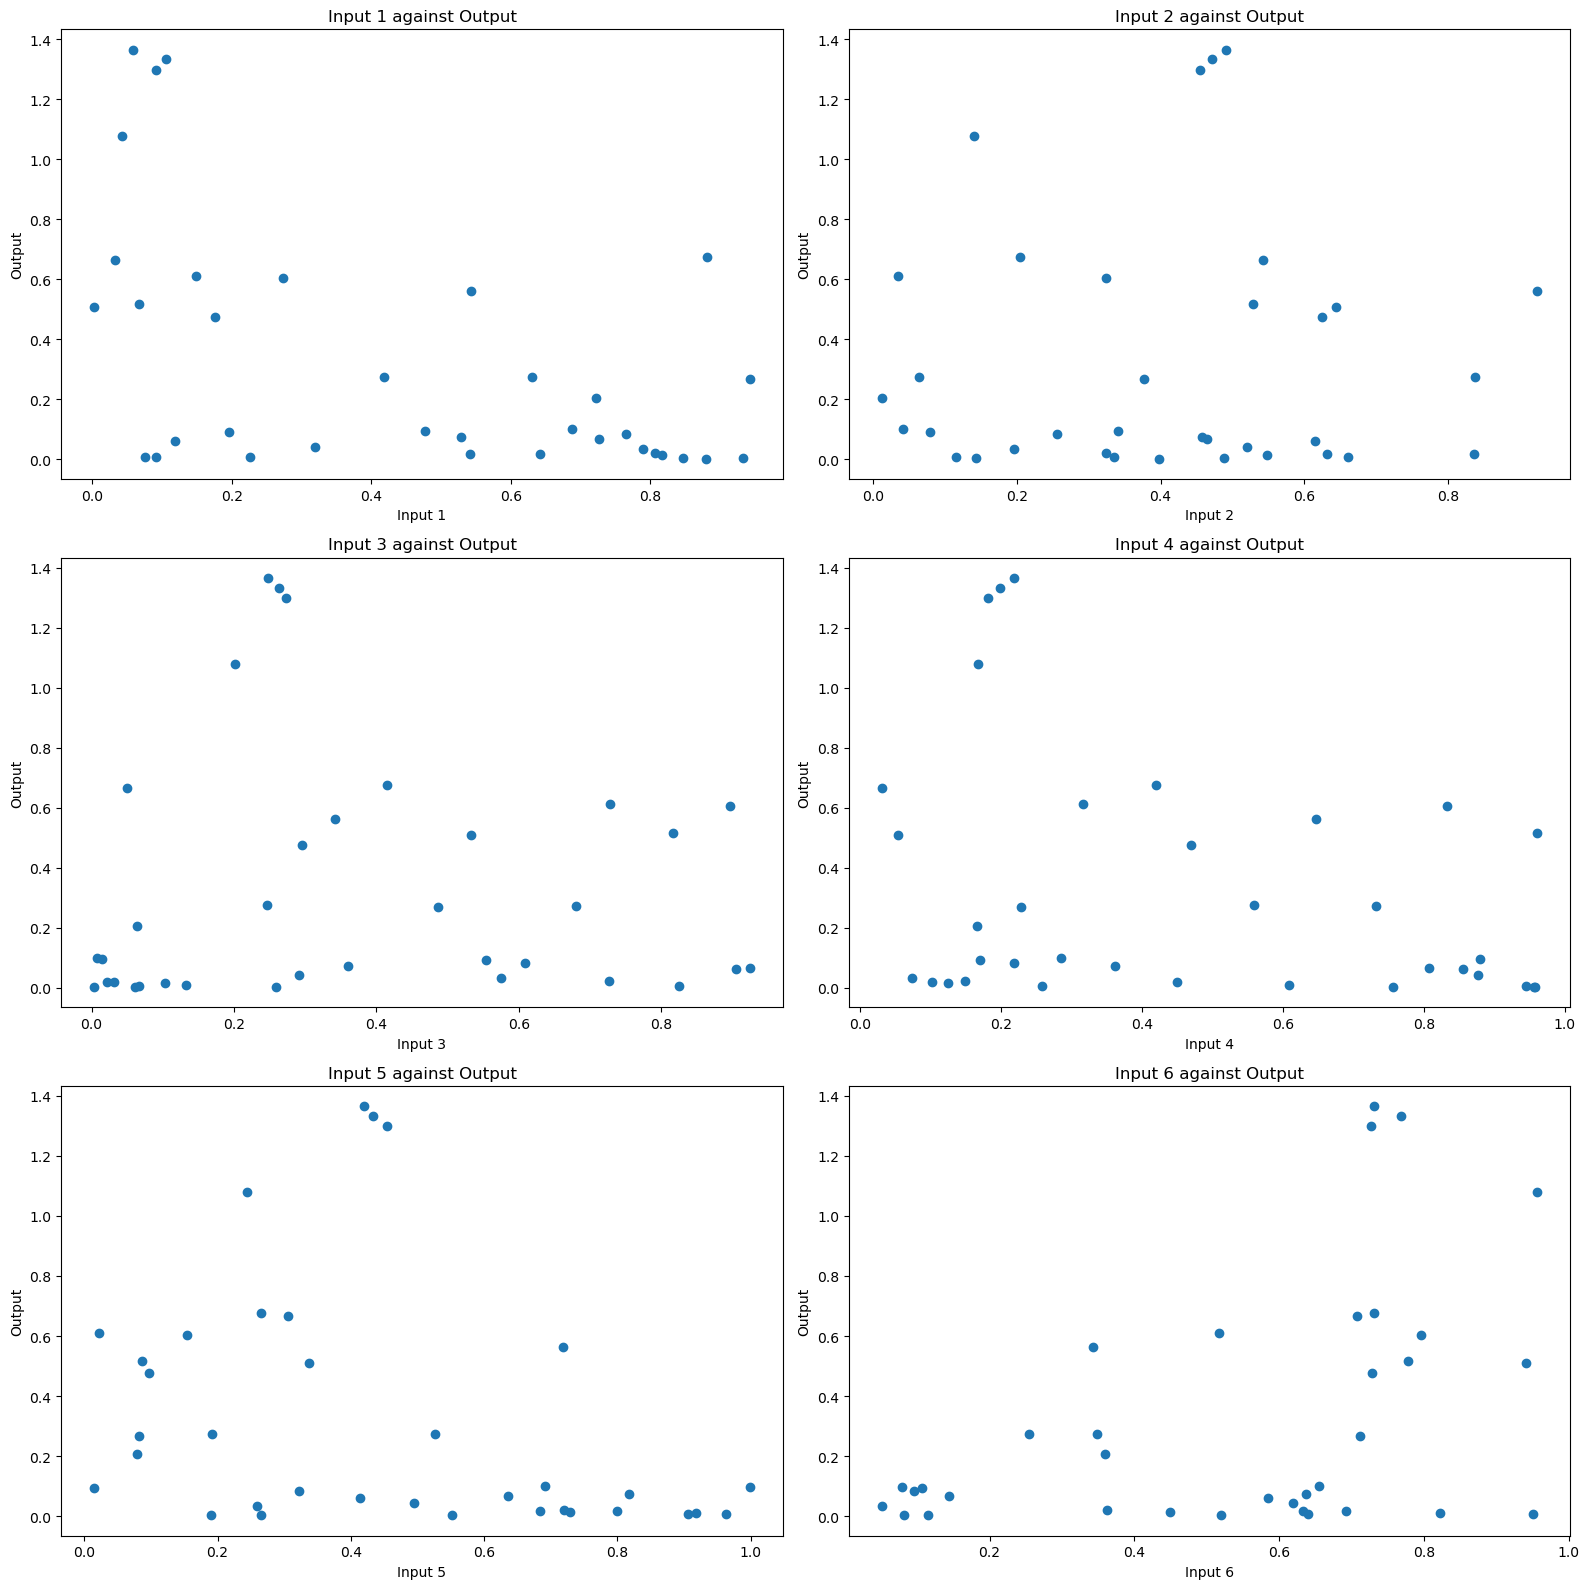

In [6]:
#Plotting each Input against the output
import matplotlib.pyplot as plt
fig, ax = plt.subplots(3,2, figsize = (16,16))

ax[0][0].scatter(X[:,0], Y)
ax[0][1].scatter(X[:,1], Y)
ax[1][0].scatter(X[:,2], Y)
ax[1][1].scatter(X[:,3], Y)
ax[2][0].scatter(X[:,4], Y)
ax[2][1].scatter(X[:,5], Y)

#Creating titles and axis labels
ax[0][0].set_title('Input 1 against Output')
ax[0][1].set_title('Input 2 against Output')
ax[1][0].set_title('Input 3 against Output')
ax[1][1].set_title('Input 4 against Output')
ax[2][0].set_title('Input 5 against Output')
ax[2][1].set_title('Input 6 against Output')

ax[0][0].set_xlabel('Input 1')
ax[0][0].set_ylabel('Output')

ax[0][1].set_xlabel('Input 2')
ax[0][1].set_ylabel('Output')

ax[1][0].set_xlabel('Input 3')
ax[1][0].set_ylabel('Output')

ax[1][1].set_xlabel('Input 4')
ax[1][1].set_ylabel('Output')

ax[2][0].set_xlabel('Input 5')
ax[2][0].set_ylabel('Output')

ax[2][1].set_xlabel('Input 6')
ax[2][1].set_ylabel('Output')

plt.tight_layout()
plt.show()

In [10]:
#We now set the Kernel to be the Matern Kernel
nu = 2.5
kernel = Matern(length_scale=1.0, length_scale_bounds= (1e-2,1e1), nu = nu)
gp_best = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-10,
    normalize_y = True)
gp_best.fit(X,Y)
#Use latin hypercube sampling to create a set of candidate points 
d = 6
n = 800000
sampler = qmc.LatinHypercube(d, seed = 42)
grid = sampler.random(n)   # samples in [0,1]^d

#Fit the GP regressor to the candidate points
mu, std = gp_best.predict(grid, return_std = True)

In [11]:
#Calculating expected improvement
best_y = np.max(Y)
eta = 0.01
z = (mu - best_y - eta) / (std + 1e-12)
ei = (mu - best_y - eta ) * norm.cdf(z) + std * norm.pdf(z)
#Find Candidate value that maximises expected improvement 
best_idx = np.argmax(ei)
x_next = grid[best_idx]
np.round(x_next,6)

array([0.012844, 0.343813, 0.218224, 0.285858, 0.348912, 0.753879])

In [12]:
#Calculate UCB as comparison
beta = 3.5 #set exploration parameter
UCB = mu + beta * std
#Find candidate that 
best_idx = np.argmax(UCB)
x_next = grid[best_idx]
np.round(x_next,6)

array([0.004636, 0.207768, 0.404112, 0.351555, 0.401196, 0.792288])